# Week 21-1 · OTS-06 — Creating an Options Backtesting Model
### Executed practice notebook on **real SPX 2023 options data**

This rebuilds the three shipped in-class notebooks — *Data Download & Processing*, *Long Call Backtester*, and *Long Strangle Backtester* — on the **real SPX end-of-day option chains** that ship with the exercise (sourced from **optionsDX**, 2023 Q1-Q4). We build a **pandas-only, event-based backtester** from scratch: load → classify by expiry → filter for liquidity → tag key trading days → simulate execution day-by-day → judge the result with trade- and strategy-level analytics.

**Data** (`spx_monthly_2023.csv`, extracted from the shipped ZIP): one row per option quote, full Greeks, IV, bid/ask, and `strike_distance_pct`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

options_monthly = pd.read_csv('spx_monthly_2023.csv', index_col=0)
options_monthly['expire_date'] = pd.to_datetime(options_monthly['expire_date'])
options_monthly['quote_date']  = pd.to_datetime(options_monthly['quote_date'])
options_monthly.index = options_monthly['quote_date']
print('rows:', len(options_monthly), '| unique quote days:', options_monthly.index.nunique())
print('underlying SPX:', options_monthly['underlying_last'].iloc[0], '->', options_monthly['underlying_last'].iloc[-1])
print('columns:', list(options_monthly.columns)[:12], '...')

rows: 51527 | unique quote days: 175
underlying SPX: 3853.39 -> 4755.11
columns: ['quote_date', 'underlying_last', 'symbol', 'expire_date', 'dte', 'c_delta', 'c_gamma', 'c_vega', 'c_theta', 'c_rho', 'c_iv', 'c_volume'] ...


## 1 · Data download & processing (the first shipped notebook)

The raw feed is **compressed `.7z` archives of daily SPX chains** (millions of rows). The shipped *Data Download & Processing* notebook does three things, which produced the clean CSV we just loaded:

1. **Extract** the `.7z` files with `py7zr` and `pd.concat` the monthly CSVs into one frame.
2. **Standardise columns** — the raw headers look like `[QUOTE_UNIXTIME]`, `[C_DELTA]`, `[STRIKE]`; strip the brackets/quotes/spaces and lower-case: `options.columns = options.columns.str.strip("[]").str.replace("'","").str.replace(" ","_").str.lower()`.
3. **Convert dtypes** — Greeks/prices to `float`, dates to `datetime`, and trim whitespace from text fields.

Our loaded frame is already clean, so we can inspect the key fields directly.

In [2]:
# the fields that matter, grouped by category
meta  = ['symbol', 'expire_date', 'dte', 'strike', 'strike_distance_pct', 'expiry_type']
calls = ['c_delta', 'c_iv', 'c_bid', 'c_ask', 'c_last', 'c_volume']
puts  = ['p_delta', 'p_iv', 'p_bid', 'p_ask', 'p_last', 'p_volume']
print(options_monthly.loc['2023-01-04', meta + ['c_last', 'p_last']].head(4).to_string())

           symbol expire_date   dte  strike  strike_distance_pct expiry_type   c_last  p_last
quote_date                                                                                   
2023-01-04    SPX  2023-01-20  16.0   200.0                0.948  Near Month  3618.19    0.03
2023-01-04    SPX  2023-01-20  16.0   400.0                0.896  Near Month  3636.80    0.05
2023-01-04    SPX  2023-01-20  16.0   600.0                0.844  Near Month  3246.91    0.10
2023-01-04    SPX  2023-01-20  16.0   800.0                0.792  Near Month  3221.90    0.05


## 2 · Expiry classification

Options are tagged by **time to expiry** so a strategy can pick the right series. The shipped `get_expiry_type()` logic:

- **LEAPS** — `days_to_expiry ≥ 365`
- **Monthly** — expiry is the **third Friday** (near / next / far / later month)
- **Weekly** — any *other* Friday
- **Daily** — everything else

The shipped data already carries this in the `expiry_type` column.

In [3]:
print(options_monthly['expiry_type'].value_counts())
print('\ndays-to-expiry range:', int(options_monthly['dte'].min()), '->', int(options_monthly['dte'].max()))

expiry_type
Near Month    51527
Name: count, dtype: int64

days-to-expiry range: 0 -> 22


## 3 · Contract filtering — keep only liquid, tradable quotes

Backtesting an illiquid quote is fiction. The shipped filters (already applied to this file) remove:
`c_last>0 & p_last>0` (actually traded), `c_size/p_size != '0 x 0'` (real market depth), non-zero **bid & ask**, and rows with a missing **IV**. We show the effect of the *active-contract* filter as an illustration.

In [4]:
before = len(options_monthly)
active = options_monthly[(options_monthly['c_last'] > 0.0) & (options_monthly['p_last'] > 0.0)]
print(f'active-price filter: {before} -> {len(active)} rows ({100*len(active)/before:.1f}% kept)')
print('ATM proximity: strike_distance_pct min =', round(options_monthly['strike_distance_pct'].min(), 4),
      '(0 = exactly at-the-money)')

active-price filter: 51527 -> 32878 rows (63.8% kept)
ATM proximity: strike_distance_pct min = 0.0 (0 = exactly at-the-money)


## 4 · Tag the key trading days (event triggers)

The engine is **event-based**: it acts only on meaningful days, not every bar. For each calendar month we mark the **first** trading day (our entry trigger) and the **day before expiry** (our exit trigger).

In [5]:
per_month = options_monthly.groupby(options_monthly.index.to_period('M'))
first_days = per_month.apply(lambda x: x.index.min())
last_days  = per_month.apply(lambda x: x.index.max())

def _day_before_last(group):
    s = group.sort_index()
    return s.index[-2] if len(s) > 1 else None
dbl_days = per_month.apply(_day_before_last)

def _day_before_expiry(group):
    exp = pd.to_datetime(group['expire_date'].iloc[0])
    s = pd.to_datetime(group.sort_index().index)
    d = s[s < exp].max()
    return d if pd.notna(d) else None
dbe_days = per_month.apply(_day_before_expiry)

first_set = set(pd.to_datetime(first_days.values))
last_set  = set(pd.to_datetime(last_days.values))
dbl_set   = set(pd.to_datetime(dbl_days.dropna().values))
dbe_set   = set(pd.to_datetime(dbe_days.dropna().values))

def assign_trading_day(date):
    if date in first_set:  return 'first'
    if date in last_set:   return 'last'
    if date in dbl_set:    return 'day_before_last'
    if date in dbe_set:    return 'day_before_expiry'
    return 'regular'

underlying_data = options_monthly['underlying_last'].drop_duplicates().to_frame()
underlying_data['trading_day'] = underlying_data.index.map(assign_trading_day)
print(underlying_data['trading_day'].value_counts())
# sanity: equal number of 'first', 'last', and 'day_before_expiry' months
print('12 entries & 12 expiries?',
      (underlying_data.trading_day == 'first').sum(),
      (underlying_data.trading_day == 'day_before_expiry').sum())

trading_day
regular              139
first                 12
day_before_expiry     12
last                  12
Name: count, dtype: int64
12 entries & 12 expiries? 12 12


## 5 · The strategy setup — ATM long call

A strategy is just a small table of legs. `setup_longcall()` finds the **at-the-money** strike (smallest `strike_distance_pct`), buys one call (`position = +1`), and reads its premium from `c_last`.

In [6]:
def get_premium(leg, chain):
    if leg['Option Type'] == 'CE':
        v = chain[chain['strike'] == leg['Strike Price']]['c_last'].values
    else:
        v = chain[chain['strike'] == leg['Strike Price']]['p_last'].values
    return v[0] if len(v) else np.nan

def setup_longcall(chain, direction='long'):
    atm = chain[chain['strike_distance_pct'] == chain['strike_distance_pct'].min()]['strike'].values[0]
    leg = pd.DataFrame({'Option Type': ['CE'], 'Strike Price': [atm], 'position': [1]})
    if direction == 'short':
        leg['position'] *= -1
    leg['premium'] = leg.apply(lambda r: get_premium(r, chain), axis=1)
    return leg

demo = setup_longcall(options_monthly.loc['2023-01-04'])
print('First trade setup (2023-01-04):')
print(demo.to_string(index=False))

First trade setup (2023-01-04):
Option Type  Strike Price  position  premium
         CE        3855.0         1     59.6


## 6 · The event-based backtest engine

One loop over the trading days. **Enter** an ATM long call on the *first* day of a month when flat; **mark-to-market** every day held; **exit** the day before expiry. Every round trip is recorded.

In [7]:
def run_backtest(setup_fn, exit_on='day_before_expiry', stoploss=None, takeprofit=None):
    round_trips, mtm_rows = [], []
    position, entry_leg, entry_prem, entry_date = 0, None, None, None
    for i in underlying_data.index:
        tag = underlying_data.loc[i, 'trading_day']
        chain = options_monthly.loc[i]
        if position == 0 and tag == 'first':
            entry_leg = setup_fn(chain)
            entry_prem = (entry_leg.position * entry_leg.premium).sum()
            entry_date, position = i, 1
            for _, l in entry_leg.iterrows():
                mtm_rows.append({'Date': i, 'Strike Price': l['Strike Price'], 'position': l['position'], 'premium': l['premium']})
        elif position == 1:
            cur = entry_leg.copy()
            cur['premium'] = cur.apply(lambda r: get_premium(r, chain), axis=1)
            cur['premium'] = cur['premium'].ffill()
            net = (cur.position * cur.premium).sum()
            for _, l in cur.iterrows():
                mtm_rows.append({'Date': i, 'Strike Price': l['Strike Price'], 'position': l['position'], 'premium': l['premium']})
            ret = (net - entry_prem) / abs(entry_prem)
            exit_type = None
            if stoploss is not None and ret <= stoploss:      exit_type = 'Stoploss'
            elif takeprofit is not None and ret >= takeprofit: exit_type = 'Take Profit'
            elif tag == exit_on:                                exit_type = 'Expiry'
            if exit_type:
                round_trips.append({'entry_date': entry_date, 'exit_date': i, 'exit_type': exit_type,
                                    'entry_price': entry_prem, 'exit_price': net})
                position = 0
    return pd.DataFrame(round_trips), pd.DataFrame(mtm_rows)

lc_trips, lc_mtm = run_backtest(setup_longcall)
print(f'Long-call round trips: {len(lc_trips)}')
print(lc_trips[['entry_date','exit_date','exit_type','entry_price','exit_price']].head(4).to_string(index=False))

Long-call round trips: 12
entry_date  exit_date exit_type  entry_price  exit_price
2023-01-04 2023-01-19    Expiry        59.60       58.86
2023-02-01 2023-02-16    Expiry        64.30        2.31
2023-03-01 2023-03-23    Expiry        83.50       24.06
2023-04-03 2023-04-20    Expiry        59.52        8.18


## 7 · The trade sheet — P&L, turnover, costs

Scale to a **lot size of 50**, compute per-trade P&L, and subtract **1% of turnover** for costs & slippage.

In [8]:
lot_size = 50
def trade_sheet(trips):
    t = trips.copy()
    t['pnl'] = (t['exit_price'] - t['entry_price']) * lot_size
    t['turnover'] = (t['exit_price'] + t['entry_price']) * lot_size
    t['pnl_post_costs'] = t['pnl'] - t['turnover'] * 0.01
    t['holding_period'] = (pd.to_datetime(t['exit_date']) - pd.to_datetime(t['entry_date'])).dt.days
    return t

lc = trade_sheet(lc_trips)
print(lc[['entry_date','exit_date','pnl','turnover','pnl_post_costs','holding_period']].to_string(index=False))

entry_date  exit_date     pnl  turnover  pnl_post_costs  holding_period
2023-01-04 2023-01-19   -37.0    5923.0         -96.230              15
2023-02-01 2023-02-16 -3099.5    3330.5       -3132.805              15
2023-03-01 2023-03-23 -2972.0    5378.0       -3025.780              22
2023-04-03 2023-04-20 -2567.0    3385.0       -2600.850              17
2023-05-01 2023-05-18 -1011.5    4518.5       -1056.685              17
2023-06-01 2023-06-22  5988.0   11628.0        5871.720              21
2023-07-03 2023-07-20  2611.0    7044.0        2540.560              17
2023-08-01 2023-08-17 -2475.0    2485.0       -2499.850              16
2023-09-01 2023-09-21 -2532.0    2539.0       -2557.390              20
2023-10-02 2023-10-19 -2388.5    3178.5       -2420.285              17
2023-11-01 2023-11-16 10901.5   15611.5       10745.385              15
2023-12-01 2023-12-21  3785.0    8965.0        3695.350              20


## 8 · Trade-level performance summary

In [9]:
def performance_summary(t):
    total = t['pnl_post_costs'].sum()
    n = len(t)
    winners = t[t['pnl'] >= 0]; losers = t[t['pnl'] < 0]
    win_pct = 100 * len(winners) / n
    avg_win = winners['pnl'].mean() if len(winners) else 0
    avg_loss = abs(losers['pnl'].mean()) if len(losers) else 0
    loss_pct = 100 * len(losers) / n
    pf = (win_pct * avg_win) / (loss_pct * avg_loss) if loss_pct * avg_loss else np.nan
    print(f'Total PnL (post-costs): ${total:,.2f}')
    print(f'Total trades: {n}   winners: {len(winners)}   losers: {len(losers)}')
    print(f'Win %: {win_pct:.2f}   |   avg win ${avg_win:,.2f}   avg loss ${avg_loss:,.2f}')
    print(f'Profit factor: {pf:.2f}   |   avg holding: {t["holding_period"].mean():.0f} days')
    return total, win_pct, pf

performance_summary(lc);

Total PnL (post-costs): $5,463.14
Total trades: 12   winners: 4   losers: 8
Win %: 33.33   |   avg win $5,821.38   avg loss $2,135.31
Profit factor: 1.36   |   avg holding: 18 days


**The honest result.** Twelve monthly ATM long-call trades on real SPX 2023 earned **≈ $5,463** after costs, but won only **33%** of the time — the classic long-option shape: *many small premium losses, a few large winners*. A **profit factor of 1.36** (gross profit ÷ gross loss > 1) is what keeps it positive despite the low hit-rate.

## 9 · Equity curve & drawdown

In [10]:
lc = lc.sort_values('entry_date').reset_index(drop=True)
initial_capital = 100000
lc['equity'] = initial_capital + lc['pnl_post_costs'].cumsum()
final_eq = lc['equity'].iloc[-1]
print(f'Equity: ${initial_capital:,} -> ${final_eq:,.0f}  ({100*(final_eq/initial_capital-1):+.2f}% on capital)')

# drawdown on the trade equity curve
eq = lc['equity'].values
running_max = np.maximum.accumulate(eq)
dd = (eq - running_max) / running_max
print(f'Max drawdown (trade equity): {dd.min():.2%}')

Equity: $100,000 -> $105,463  (+5.46% on capital)
Max drawdown (trade equity): -9.83%


**A pitfall from the shipped notebook.** Its *strategy analytics* divide each day's P&L by a tiny **margin** figure to make a daily return, then annualise. Because the denominator is so small and jumps around, that path prints an alarming **CAGR ≈ −67%, Sharpe ≈ −3.3, drawdown ≈ −99.9%** — even though the trades net a **profit**. The lesson (which the shipped notebook flags too): *a −99.9% "drawdown" is an artifact of margin-normalised returns for a long-option book*; judge the strategy by the **trade-level P&L and profit factor**, not that unstable ratio.

## 10 · Reusing the engine — a long strangle

The engine is strategy-agnostic: swap only the **setup function**. A **long strangle** buys the OTM call just below ATM and the OTM put just above it — a bet on a *big move either way*.

In [11]:
def setup_long_strangle(chain, direction='long'):
    c = chain.reset_index(drop=True)
    pos = c['strike_distance_pct'].argmin()
    call_strike = c.iloc[pos - 1]['strike']   # OTM call
    put_strike  = c.iloc[pos + 1]['strike']   # OTM put
    leg = pd.DataFrame({'Option Type': ['CE','PE'], 'Strike Price': [call_strike, put_strike], 'position': [1,1]})
    leg['premium'] = leg.apply(lambda r: get_premium(r, chain), axis=1)
    return leg

ls_trips, _ = run_backtest(setup_long_strangle)
ls = trade_sheet(ls_trips)
print('LONG STRANGLE:')
performance_summary(ls);

LONG STRANGLE:
Total PnL (post-costs): $-7,704.88
Total trades: 12   winners: 6   losers: 6
Win %: 50.00   |   avg win $3,671.25   avg loss $4,733.50
Profit factor: 0.78   |   avg holding: 18 days


## 11 · Extending the engine — stop-loss / take-profit

Real risk management exits early. Re-run the long call with a **−20% stop-loss** and **+40% take-profit** on the premium.

In [12]:
lc_sltp_trips, _ = run_backtest(setup_longcall, stoploss=-0.20, takeprofit=0.40)
lc_sltp = trade_sheet(lc_sltp_trips)
print('LONG CALL with -20% SL / +40% TP:')
performance_summary(lc_sltp)
print('\nexit-type counts:', dict(lc_sltp_trips['exit_type'].value_counts()))

LONG CALL with -20% SL / +40% TP:
Total PnL (post-costs): $1,498.69
Total trades: 12   winners: 5   losers: 7
Win %: 41.67   |   avg win $1,934.70   avg loss $1,067.86
Profit factor: 1.29   |   avg holding: 2 days

exit-type counts: {'Stoploss': np.int64(7), 'Take Profit': np.int64(5)}


## 12 · The four pictures of OTS-06

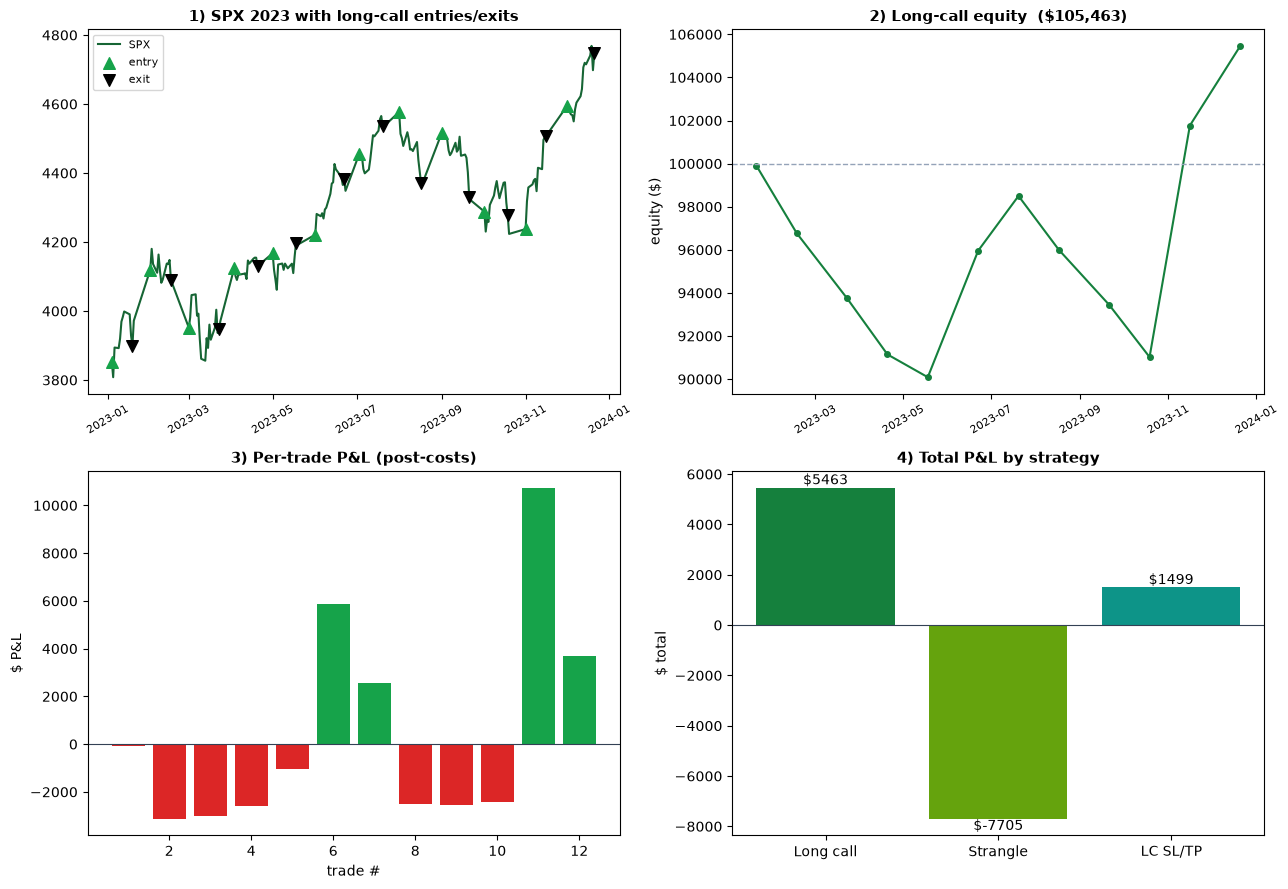

saved chart_1_backtest.png


In [13]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# (1) underlying with entry/exit markers
a = ax[0,0]
a.plot(underlying_data.index, underlying_data['underlying_last'], color='#166534', lw=1.5, label='SPX')
a.scatter(pd.to_datetime(lc['entry_date']), underlying_data.loc[pd.to_datetime(lc['entry_date']), 'underlying_last'],
          color='#16a34a', marker='^', s=70, zorder=3, label='entry')
a.scatter(pd.to_datetime(lc['exit_date']), underlying_data.loc[pd.to_datetime(lc['exit_date']), 'underlying_last'],
          color='black', marker='v', s=70, zorder=3, label='exit')
a.set_title('1) SPX 2023 with long-call entries/exits', fontsize=11, weight='bold')
a.legend(fontsize=8); a.tick_params(axis='x', labelrotation=30, labelsize=8)

# (2) equity curve
a = ax[0,1]
a.plot(pd.to_datetime(lc['exit_date']), lc['equity'], marker='o', ms=4, color='#15803d')
a.axhline(initial_capital, color='#94a3b8', ls='--', lw=1)
a.set_title(f'2) Long-call equity  (${final_eq:,.0f})', fontsize=11, weight='bold')
a.set_ylabel('equity ($)'); a.tick_params(axis='x', labelrotation=30, labelsize=8)

# (3) per-trade PnL bars
a = ax[1,0]
colors = ['#16a34a' if p >= 0 else '#dc2626' for p in lc['pnl_post_costs']]
a.bar(range(1, len(lc)+1), lc['pnl_post_costs'], color=colors)
a.axhline(0, color='#334155', lw=0.8)
a.set_title('3) Per-trade P&L (post-costs)', fontsize=11, weight='bold')
a.set_xlabel('trade #'); a.set_ylabel('$ P&L')

# (4) strategy comparison bars
a = ax[1,1]
names = ['Long call', 'Strangle', 'LC SL/TP']
totals = [lc['pnl_post_costs'].sum(), ls['pnl_post_costs'].sum(), lc_sltp['pnl_post_costs'].sum()]
bars = a.bar(names, totals, color=['#15803d', '#65a30d', '#0d9488'])
a.axhline(0, color='#334155', lw=0.8); a.bar_label(bars, fmt='$%.0f')
a.set_title('4) Total P&L by strategy', fontsize=11, weight='bold'); a.set_ylabel('$ total')

plt.tight_layout()
plt.savefig('chart_1_backtest.png', dpi=110, bbox_inches='tight')
plt.show()
print('saved chart_1_backtest.png')

## Summary — the OTS-06 backtesting pipeline
1. **Collect & clean** real optionsDX SPX chains (`.7z` → concat → standardise columns → fix dtypes).
2. **Classify** by expiry (LEAPS / Monthly / Weekly / Daily) and **filter** for liquidity (traded price, bid/ask, IV).
3. **Tag events** — first-of-month (entry) and day-before-expiry (exit).
4. **Simulate** with one strategy-agnostic engine; swap only the `setup_*` function (long call, strangle, …).
5. **Analyse honestly** — real 2023 long call: **12 trades, ≈ $5,463 profit, 33% win, profit factor 1.36**; beware margin-normalised ratios that cry −99.9%.
6. **Extend** with stop-loss / take-profit, position sizing, and IV/VIX entry filters — and always watch for **look-ahead bias**.